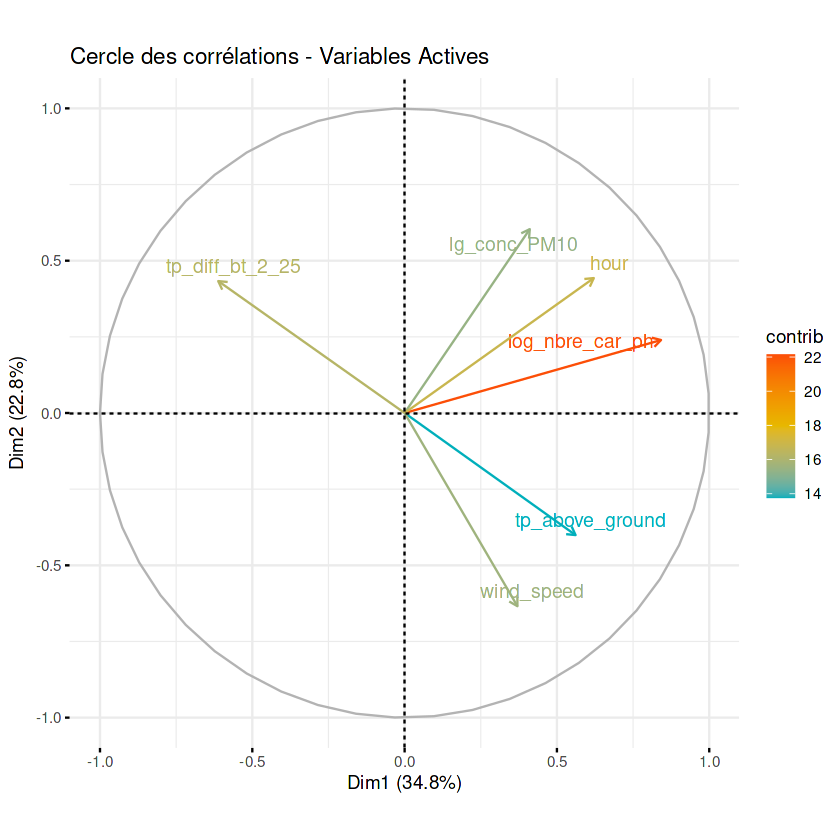

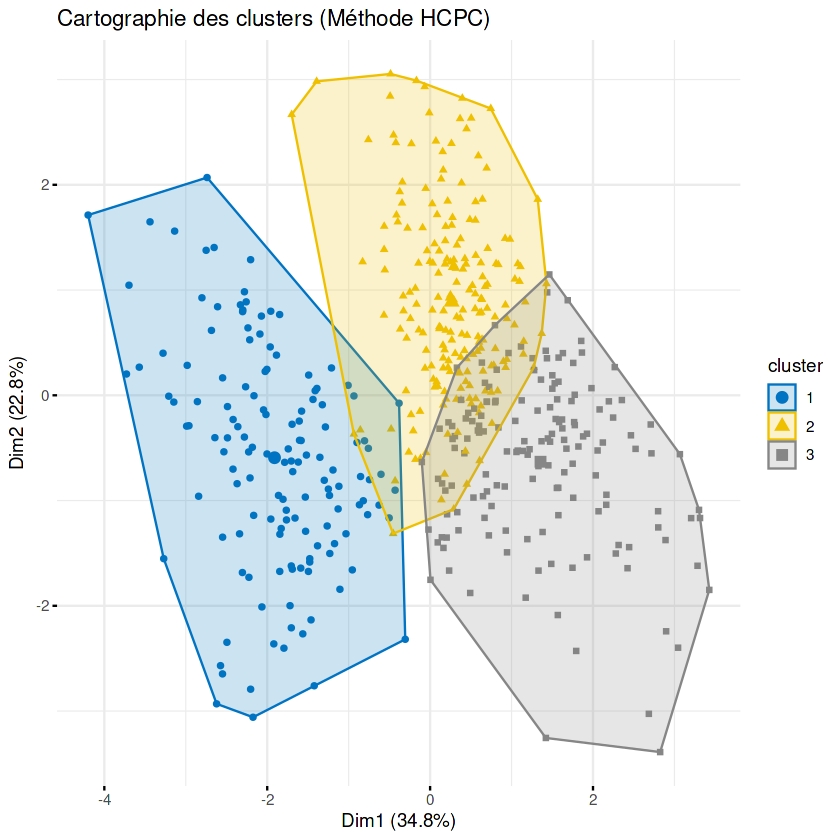

In [13]:
library(FactoMineR)
library(factoextra)
# Lecture du fichier PM10.dat
df <- read.table("/kaggle/input/datasets/vidushanr/pm10-dat/PM10.dat", header = TRUE, sep = "")


colnames(df) <- c("lg_conc_PM10", "log_nbre_car_ph", "tp_above_ground", 
                  "wind_speed", "tp_diff_bt_2_25", "wind_direction", 
                  "hour", "day")
# 1. On s'assure que l'ACP est bien stockée
res_acp <- PCA(df[, c(1, 2, 3, 4, 5,7)], scale.unit = TRUE, graph = FALSE)

# 2. La fonction HCPC 

res_hcpc <- HCPC(res_acp, nb.clust = -1, graph = FALSE)

# 3. Visualisation
# Visualisation des variables
fviz_pca_var(res_acp, 
             col.var = "contrib", # Couleur selon la contribution à l'axe
             gradient.cols = c("#00AFBB", "#E7B800", "#FC4E07"),
             repel = TRUE, # Évite le chevauchement des textes
             title = "Cercle des corrélations - Variables Actives")
# Visualisation des individus regroupés par clusters
fviz_cluster(res_hcpc,
             geom = "point", # On affiche les points sans les noms (trop nombreux)
             main = "Cartographie des clusters (Méthode HCPC)",
             palette = "jco", # Palette de couleurs professionnelle
             ggtheme = theme_minimal())